<a href="https://colab.research.google.com/github/nhermy/CSB-SJUCSCapstone/blob/main/finalGNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch_geometric statsbombpy mplsoccer -q

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing
from scipy.spatial import Delaunay
from statsbombpy import sb
from collections import Counter
import random
import warnings

# --- Global Configuration ---
FORMATION_MAP = {'433': 0, '442': 1, '4231': 2, '352': 3, '4141': 4}
NUM_CLASSES = len(FORMATION_MAP)
TAU = 15  # Number of frames per sequence
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {DEVICE}")

Using device: cpu


In [ ]:
def get_improved_role_mapping(match_id):
    lineups = sb.lineups(match_id=match_id)
    player_to_role = {}
    DEF_IDS, MID_IDS, FWD_IDS = {2,3,4,5,17,18}, {6,7,8,9,10,11}, {12,13,14,15,16,23}

    for team, lineup in lineups.items():
        for _, p in lineup.iterrows():
            pos_id = p['positions'][0]['position_id'] if p['positions'] else 0
            if pos_id == 1: role = 'GK'
            elif pos_id in DEF_IDS: role = 'DEF'
            elif pos_id in MID_IDS: role = 'MID'
            else: role = 'FWD'
            player_to_role[p['player_name']] = role
    return player_to_role

def extract_formations(match_id):
    events_df = sb.events(match_id=match_id)
    tactical = events_df[events_df['type'].isin(['Starting XI', 'Tactical Shift'])]
    rows = []
    for _, row in tactical.iterrows():
        tactics = row['tactics']
        if isinstance(tactics, dict) and 'formation' in tactics:
            rows.append({'team': row['team'], 'minute': row['minute'], 'formation': str(tactics['formation'])})
    return pd.DataFrame(rows)

def build_frame_graph(frame_data, player_to_role):
    team_frame = frame_data[frame_data['teammate'] == True]
    if len(team_frame) < 3: return None
    feats, coords = [], []
    for _, p in team_frame.iterrows():
        x, y = p['location']
        role = player_to_role.get(p.get('player'), 'FWD')
        feats.append([x/120.0, y/80.0, 1.0 if p.get('actor') else 0.0,
                      1.0 if role == 'GK' else 0.0, 1.0 if role == 'DEF' else 0.0,
                      1.0 if role == 'MID' else 0.0, 1.0 if role == 'FWD' else 0.0])
        coords.append([x, y])

    tri = Delaunay(np.array(coords))
    edges = set()
    for s in tri.simplices:
        edges.update([(s[0],s[1]), (s[1],s[0]), (s[1],s[2]), (s[2],s[1]), (s[2],s[0]), (s[0],s[2])])

    return Data(x=torch.tensor(feats, dtype=torch.float),
                edge_index=torch.tensor(list(edges), dtype=torch.long).t().contiguous())

In [ ]:
class FormationSpatialLayer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=self.lin(x))
    def message(self, x_j): return x_j
    def update(self, aggr_out, x): return F.relu(aggr_out + x)

class FormationSTGNN(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes):
        super().__init__()
        self.conv1 = FormationSpatialLayer(num_features, hidden_dim)
        self.conv2 = FormationSpatialLayer(hidden_dim, hidden_dim)
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Sequential(nn.Linear(hidden_dim, hidden_dim//2), nn.ReLU(),
                                        nn.Dropout(0.2), nn.Linear(hidden_dim//2, num_classes))

    def forward(self, graph_sequence):
        # Process list of graphs into team embeddings
        embs = []
        for g in graph_sequence:
            x = self.conv1(g.x.to(DEVICE), g.edge_index.to(DEVICE))
            x = self.conv2(x, g.edge_index.to(DEVICE))
            embs.append(torch.mean(x, dim=0, keepdim=True))

        _, h_n = self.gru(torch.stack(embs, dim=1))
        return self.classifier(h_n.squeeze(0))

In [ ]:
all_sequences = []
# Using World Cup 2022 Match IDs
target_matches = [3869151, 3857256, 3869685]

for m_id in target_matches:
    print(f"Extracting Match {m_id}...")
    try:
        roles = get_improved_role_mapping(m_id)
        forms = extract_formations(m_id)
        events = sb.events(match_id=m_id)
        frames = sb.frames(match_id=m_id, fmt='dataframe')

        valid_evs = events[events['id'].isin(frames['id'].unique())].sort_values(['minute', 'second'])

        for i in range(len(valid_evs) - TAU):
            window = valid_evs.iloc[i : i + TAU]
            team = window.iloc[-1]['possession_team']
            f_row = forms[(forms['team'] == team) & (forms['minute'] <= window.iloc[-1]['minute'])]

            if f_row.empty or f_row.iloc[-1]['formation'] not in FORMATION_MAP: continue

            label = torch.tensor([FORMATION_MAP[f_row.iloc[-1]['formation']]], dtype=torch.long)
            seq = []
            for _, ev in window.iterrows():
                g = build_frame_graph(frames[frames['id'] == ev['id']], roles)
                if g is None: break
                seq.append(g)

            if len(seq) == TAU: all_sequences.append((seq, label))
    except Exception as e: print(f"Error: {e}")

print(f"Total Sequences Loaded: {len(all_sequences)}")

Extracting Match 3869151...


KeyboardInterrupt: 

In [ ]:
def balance_and_split(dataset, test_size=0.2):
    # 1. Count occurrences of each label
    counts = Counter([seq[1].item() for seq in dataset])
    target_count = max(counts.values())

    print(f"Original distribution: {dict(counts)}")

    # 2. Oversample minority classes
    balanced_dataset = []
    for lbl in counts:
        subset = [s for s in dataset if s[1].item() == lbl]
        balanced_dataset.extend(random.choices(subset, k=target_count))

    random.shuffle(balanced_dataset)

    # 3. Standard train/test split
    split_idx = int(len(balanced_dataset) * (1 - test_size))
    train_data = balanced_dataset[:split_idx]
    val_data = balanced_dataset[split_idx:]

    return train_data, val_data

# Execute the split
train_set, val_set = balance_and_split(all_sequences)
print(f"Balanced Dataset: {len(train_set)} Training, {len(val_set)} Validation.")

In [ ]:
# Initialize Model, Optimizer, and Loss
model = FormationSTGNN(num_features=7, hidden_dim=64, num_classes=NUM_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 15

print(f"Starting training on {DEVICE}...")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0

    # Shuffle training data each epoch
    random.shuffle(train_set)

    for seq, label in train_set:
        label = label.to(DEVICE)

        optimizer.zero_grad()

        # Forward pass: the model handles the list of graphs
        logits = model(seq)

        loss = criterion(logits, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if torch.argmax(logits, dim=1) == label:
            correct += 1

    avg_loss = total_loss / len(train_set)
    accuracy = (correct / len(train_set)) * 100

    # Validation Phase
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for seq, label in val_set:
            label = label.to(DEVICE)
            logits = model(seq)
            if torch.argmax(logits, dim=1) == label:
                val_correct += 1

    val_accuracy = (val_correct / len(val_set)) * 100

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {avg_loss:.4f} | Train Acc: {accuracy:.2f}% | Val Acc: {val_accuracy:.2f}%")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_final_results(model, val_set):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for seq, label in val_set:
            logits = model(seq)
            all_preds.append(torch.argmax(logits, dim=1).item())
            all_labels.append(label.item())

    # Map indices back to formation names
    inv_map = {v: k for k, v in FORMATION_MAP.items()}

    # FIX: Get only the unique labels present in the actual results
    present_indices = np.unique(np.concatenate([all_labels, all_preds]))
    display_labels = [inv_map[i] for i in present_indices]

    # Generate the matrix using only present labels
    cm = confusion_matrix(all_labels, all_preds, labels=present_indices)

    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

    # Plot with consistent labels
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title("Formation Classification Confusion Matrix (Dynamic Fix)")
    plt.show()

# Run the fixed block
plot_final_results(model, val_set)

In [ ]:
# Save the trained model weights
torch.save(model.state_dict(), 'formation_stgnn_v3.pth')
print("Model saved as formation_stgnn_v3.pth")

# Save the FORMATION_MAP so you can remember which index is which
import json
with open('formation_map.json', 'w') as f:
    json.dump(FORMATION_MAP, f)

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

def final_report(model, val_set):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for seq, label in val_set:
            logits = model(seq)
            y_pred.append(torch.argmax(logits, dim=1).item())
            y_true.append(label.item())

    # Map indices back to names
    inv_map = {v: k for k, v in FORMATION_MAP.items()}

    # FIX: Identify only the labels present in the ground truth
    present_labels = sorted(list(set(y_true)))
    target_names = [inv_map[i] for i in present_labels]

    print("\n--- Final Tactical Classification Report ---")
    # Pass 'labels' to ensure the report matches the target_names
    print(classification_report(y_true, y_pred, labels=present_labels, target_names=target_names))

# Run the fixed report
final_report(model, val_set)

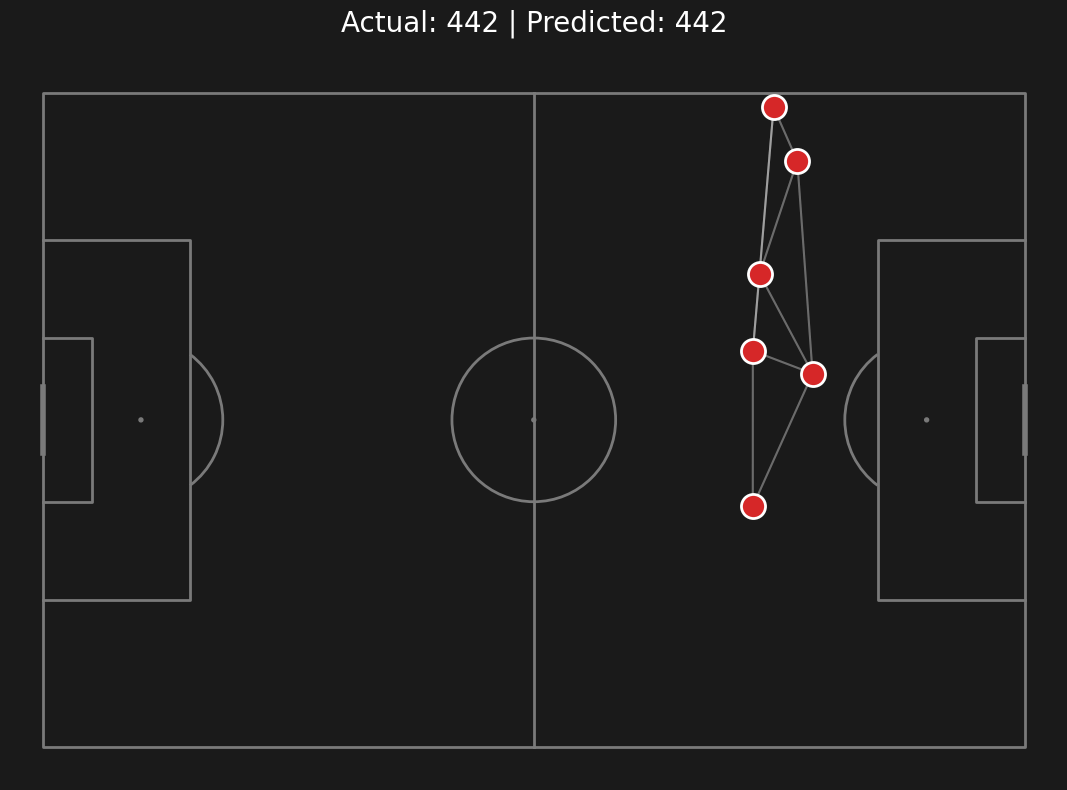

In [ ]:

from mplsoccer import Pitch
import matplotlib.pyplot as plt

def visualize_tactical_graph(model, dataset, sample_idx=None):
    model.eval()
    if sample_idx is None:
        sample_idx = random.randint(0, len(dataset) - 1)

    seq, label = dataset[sample_idx]

    with torch.no_grad():
        logits = model(seq)
        pred = torch.argmax(logits, dim=1).item()

    # We'll visualize the last frame in the TAU sequence
    last_graph = seq[-1]
    inv_map = {v: k for k, v in FORMATION_MAP.items()}

    # Denormalize coordinates (x: 0-1 -> 0-120, y: 0-1 -> 0-80)
    x_coords = last_graph.x[:, 0].numpy() * 120
    y_coords = last_graph.x[:, 1].numpy() * 80
    edges = last_graph.edge_index.numpy()

    # Set up the pitch
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1a1a', line_color='#7a7a7a')
    fig, ax = pitch.draw(figsize=(12, 8))

    # 1. Draw Delaunay Edges (The GNN's "Vision")
    for i in range(edges.shape[1]):
        u, v = edges[0, i], edges[1, i]
        ax.plot([x_coords[u], x_coords[v]], [y_coords[u], y_coords[v]],
                color='white', alpha=0.2, lw=1.5, zorder=1)

    # 2. Draw Players colored by Role
    # Features: [x, y, actor, keeper, def, mid, fwd]
    for i in range(len(x_coords)):
        role_slice = last_graph.x[i, 3:] # [keeper, def, mid, fwd]
        role_idx = torch.argmax(role_slice).item()
        colors = ['#FFD700', '#1f77b4', '#2ca02c', '#d62728'] # GK, DEF, MID, FWD

        ax.scatter(x_coords[i], y_coords[i], s=300, color=colors[role_idx],
                   edgecolors='white', linewidth=2, zorder=3)

    plt.title(f"Actual: {inv_map[label.item()]} | Predicted: {inv_map[pred]}",
              color='white', size=20, pad=20)
    fig.set_facecolor('#1a1a1a')
    plt.show()

# Run the visualization
visualize_tactical_graph(model, val_set)



Extracting team embeddings...


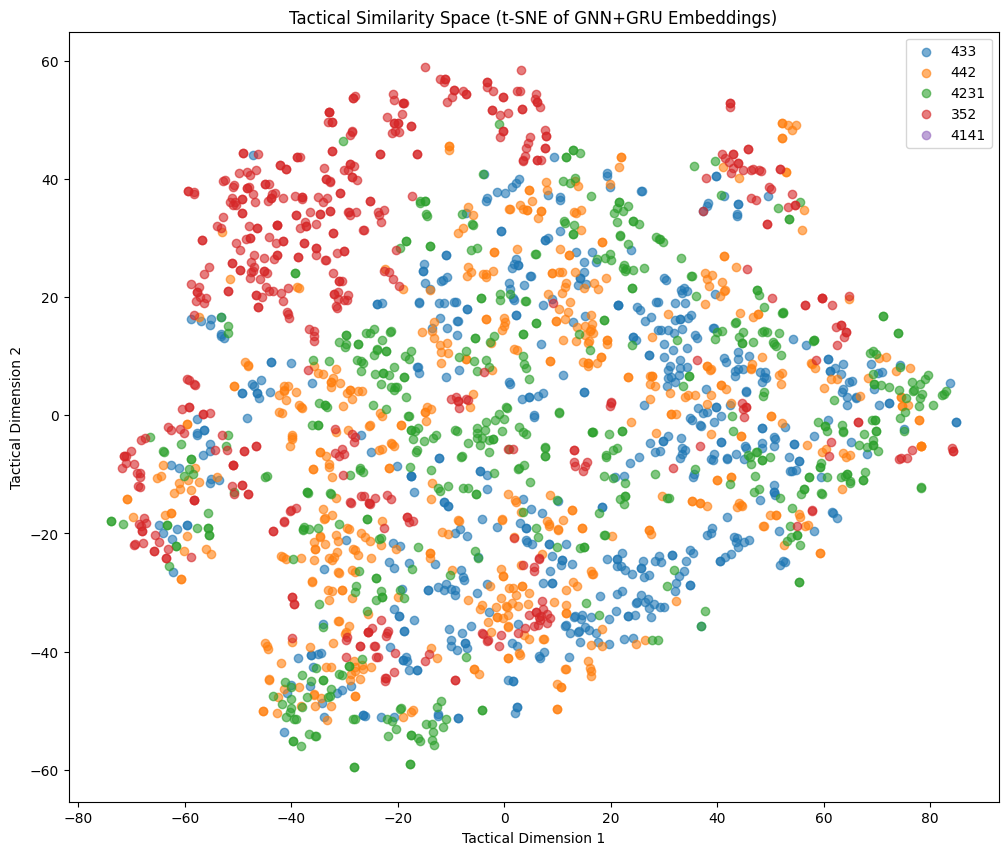

In [ ]:
from sklearn.manifold import TSNE

def plot_tactical_clusters(model, dataset):
    model.eval()
    embeddings = []
    labels = []

    print("Extracting team embeddings...")
    with torch.no_grad():
        for seq, label in dataset:
            # We bypass the final classifier to get the GRU output
            embs = []
            for g in seq:
                x = model.conv1(g.x.to(DEVICE), g.edge_index.to(DEVICE))
                x = model.conv2(x, g.edge_index.to(DEVICE))
                embs.append(torch.mean(x, dim=0, keepdim=True))

            _, h_n = model.gru(torch.stack(embs, dim=1))
            embeddings.append(h_n.squeeze().cpu().numpy())
            labels.append(label.item())

    # Project to 2D using t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    vis_dims = tsne.fit_transform(np.array(embeddings))

    plt.figure(figsize=(12, 10))
    inv_map = {v: k for k, v in FORMATION_MAP.items()}

    for i in range(NUM_CLASSES):
        points = vis_dims[np.array(labels) == i]
        plt.scatter(points[:, 0], points[:, 1], label=inv_map[i], alpha=0.6)

    plt.legend()
    plt.title("Tactical Similarity Space (t-SNE of GNN+GRU Embeddings)")
    plt.xlabel("Tactical Dimension 1")
    plt.ylabel("Tactical Dimension 2")
    plt.show()

# Run the cluster analysis
plot_tactical_clusters(model, val_set)

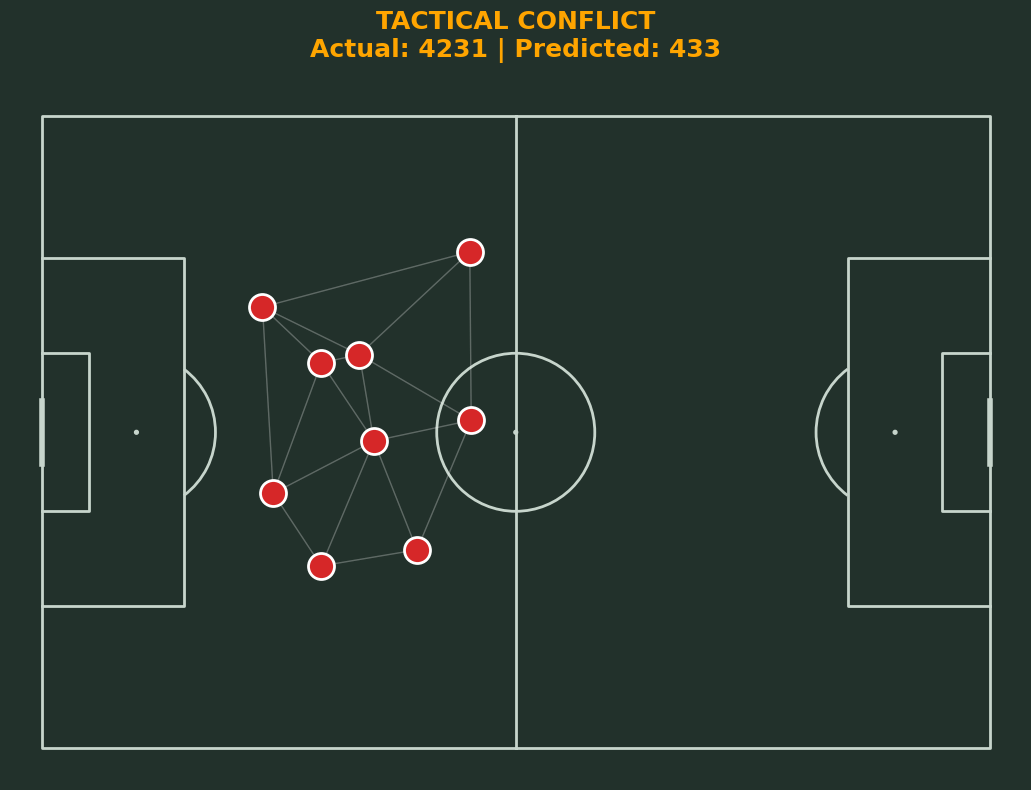

In [ ]:
def visualize_misidentification(model, dataset):
    model.eval()
    errors = []

    # 1. Find all indices where prediction != actual
    with torch.no_grad():
        for i in range(len(dataset)):
            seq, label = dataset[i]
            logits = model(seq)
            pred = torch.argmax(logits, dim=1).item()
            if pred != label.item():
                errors.append((i, pred, label.item()))

    if not errors:
        print("No misidentifications found in this dataset!")
        return

    # 2. Pick a random error to visualize
    sample_idx, pred_idx, actual_idx = random.choice(errors)
    seq, _ = dataset[sample_idx]
    last_graph = seq[-1]
    inv_map = {v: k for k, v in FORMATION_MAP.items()}

    # 3. Setup Plotting
    x_coords = last_graph.x[:, 0].numpy() * 120
    y_coords = last_graph.x[:, 1].numpy() * 80
    edges = last_graph.edge_index.numpy()

    pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
    fig, ax = pitch.draw(figsize=(12, 8))

    # Draw Delaunay edges
    for i in range(edges.shape[1]):
        u, v = edges[0, i], edges[1, i]
        ax.plot([x_coords[u], x_coords[v]], [y_coords[u], y_coords[v]],
                color='white', alpha=0.15, lw=1, zorder=1)

    # Draw Players colored by Role
    colors_map = {0: '#FFD700', 1: '#1f77b4', 2: '#2ca02c', 3: '#d62728'} # GK, DEF, MID, FWD
    for i in range(len(x_coords)):
        role_idx = torch.argmax(last_graph.x[i, 3:]).item()
        ax.scatter(x_coords[i], y_coords[i], s=350, color=colors_map[role_idx],
                   edgecolors='white', linewidth=2, zorder=3)

    # 4. Highlight the conflict
    title_text = f"TACTICAL CONFLICT\nActual: {inv_map[actual_idx]} | Predicted: {inv_map[pred_idx]}"
    plt.title(title_text, color='orange', size=18, fontweight='bold', pad=20)
    fig.set_facecolor('#22312b')
    plt.show()

# Run the error analysis
visualize_misidentification(model, val_set)

Analyzing Argentina...


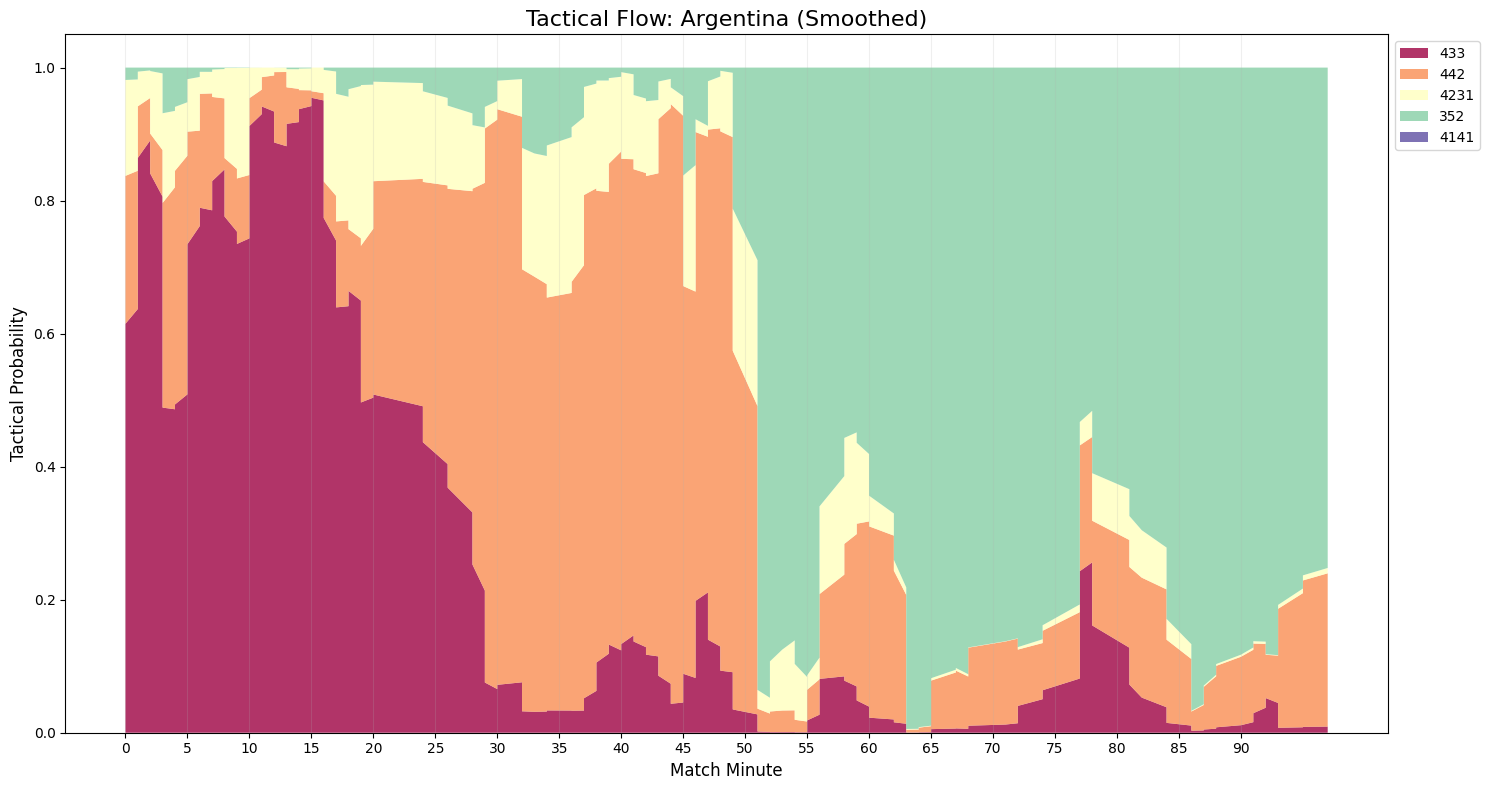

In [ ]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np

def generate_refined_viz(model, match_id, target_team_name, sigma=3):
    model.eval()
    prob_timeline = []
    minutes_list = []

    print(f"Analyzing {target_team_name}...")

    # 1. Standard Data Extraction
    roles = get_improved_role_mapping(match_id)
    events = sb.events(match_id=match_id)
    frames = sb.frames(match_id=match_id, fmt='dataframe')

    valid_ids = frames['id'].unique()
    match_events = events[
        (events['id'].isin(valid_ids)) &
        (events['possession_team'] == target_team_name)
    ].sort_values(['minute', 'second'])

    # 2. Sequential Inference
    for i in range(0, len(match_events) - TAU, 5):
        window = match_events.iloc[i : i + TAU]
        minute = window.iloc[-1]['minute']

        graph_seq = []
        skip = False
        for _, ev in window.iterrows():
            g = build_frame_graph(frames[frames['id'] == ev['id']], roles)
            if g is None:
                skip = True
                break
            graph_seq.append(g)

        if not skip:
            with torch.no_grad():
                logits = model(graph_seq)
                probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
                prob_timeline.append(probs)
                minutes_list.append(minute)

    # 3. Apply Gaussian Smoothing to remove 'branching'
    probs_array = np.array(prob_timeline).T
    smoothed_probs = np.zeros_like(probs_array)
    for i in range(probs_array.shape[0]):
        smoothed_probs[i] = gaussian_filter1d(probs_array[i], sigma=sigma)

    # Normalize so they sum to 1.0
    smoothed_probs /= smoothed_probs.sum(axis=0)

    # 4. Final Visualization
    plt.figure(figsize=(15, 8))
    inv_map = {v: k for k, v in FORMATION_MAP.items()}
    labels = [inv_map[i] for i in range(NUM_CLASSES)]

    plt.stackplot(minutes_list, smoothed_probs, labels=labels, alpha=0.8, colors=plt.cm.Spectral(np.linspace(0, 1, NUM_CLASSES)))

    plt.title(f"Tactical Flow: {target_team_name} (Smoothed)", fontsize=16)
    plt.xlabel("Match Minute", fontsize=12)
    plt.ylabel("Tactical Probability", fontsize=12)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xticks(range(0, 95, 5))
    plt.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

# Run the full pipeline for Argentina (3869151)
generate_refined_viz(model, 3869151, "Argentina", sigma=4)